In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [2]:

# Se especifica el nombre del archivo y la hoja correspondiente
file_path = '../../data/Etapa1_Base de Datos.xlsx'
sheet = 'Prisma Rectangular'

# Selección de variables predictoras
features_cat = ['Orientación', 'Tamaño', 'Posición']
features_num = ['T_media (°C)', 'HR_media']

# Definimos los objetivos (targets)
targets = ['Ancho_Promedio (mm)', 'Altura_Promedio (mm)']
targets_error = ['Error_Ancho', 'Error_Altura']


In [3]:
def run_feature_importance(file_path, sheet, features_cat, features_num, targets):
    try:
        # 1. Carga de datos desde el archivo Excel
        # Leemos el Excel. 'skiprows=1' salta la primera fila de dimensiones nominales
        df = pd.read_excel(file_path, sheet_name=sheet, skiprows=1)
        
        # Limpieza de datos (eliminamos filas con valores nulos en las columnas clave)
        columns_needed = features_cat + features_num + targets
        df_clean = df[columns_needed].dropna()
        
        # 2. Preprocesamiento (One-Hot Encoding para variables categóricas)
        # Esto convierte 'Orientación', 'Tamaño' y 'Posición' en columnas numéricas de 0 y 1
        X = pd.get_dummies(df_clean[features_cat + features_num], columns=features_cat)
        
        plt.figure(figsize=(14, 6))
        
        # 3. Entrenamiento y Extracción de Importancia para cada objetivo
        for i, target_col in enumerate(targets):
            y = df_clean[target_col]
            
            # Configuramos el modelo de Random Forest
            # n_estimators=100: número de árboles en el bosque
            # random_state=42: asegura que los resultados sean siempre los mismos
            rf = RandomForestRegressor(n_estimators=100, random_state=42)
            rf.fit(X, y)
            
            # Obtenemos la importancia de cada variable
            importances = rf.feature_importances_
            feature_names = X.columns
            feature_importance_df = pd.DataFrame({'Variable': feature_names, 'Importancia': importances})
            feature_importance_df = feature_importance_df.sort_values(by='Importancia', ascending=False)
            
            # 4. Generación de gráficos
            plt.subplot(1, 2, i+1)
            sns.barplot(x='Importancia', y='Variable', data=feature_importance_df.head(10), palette='viridis')
            plt.title(f'Importancia de Variables para: {target_col}')
            plt.xlabel('Puntuación de Importancia')
            plt.ylabel('')

        plt.tight_layout()
        plt.show()

        print(f"Análisis de la hoja '{sheet}' completado con éxito.")

    except FileNotFoundError:
        print("Error: No se encontró el archivo Excel. Asegúrate de que el nombre sea correcto.")
    except ValueError as e:
        print(f"Error: No se pudo encontrar la hoja especificada o el formato es incorrecto: {e}")
    except Exception as e:
        print(f"Ocurrió un error inesperado: {e}")

C:\Users\Erick\AppData\Local\Temp\ipykernel_41376\2360539173.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=feature_importance_df.head(10), palette='viridis')
C:\Users\Erick\AppData\Local\Temp\ipykernel_41376\2360539173.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=feature_importance_df.head(10), palette='viridis')


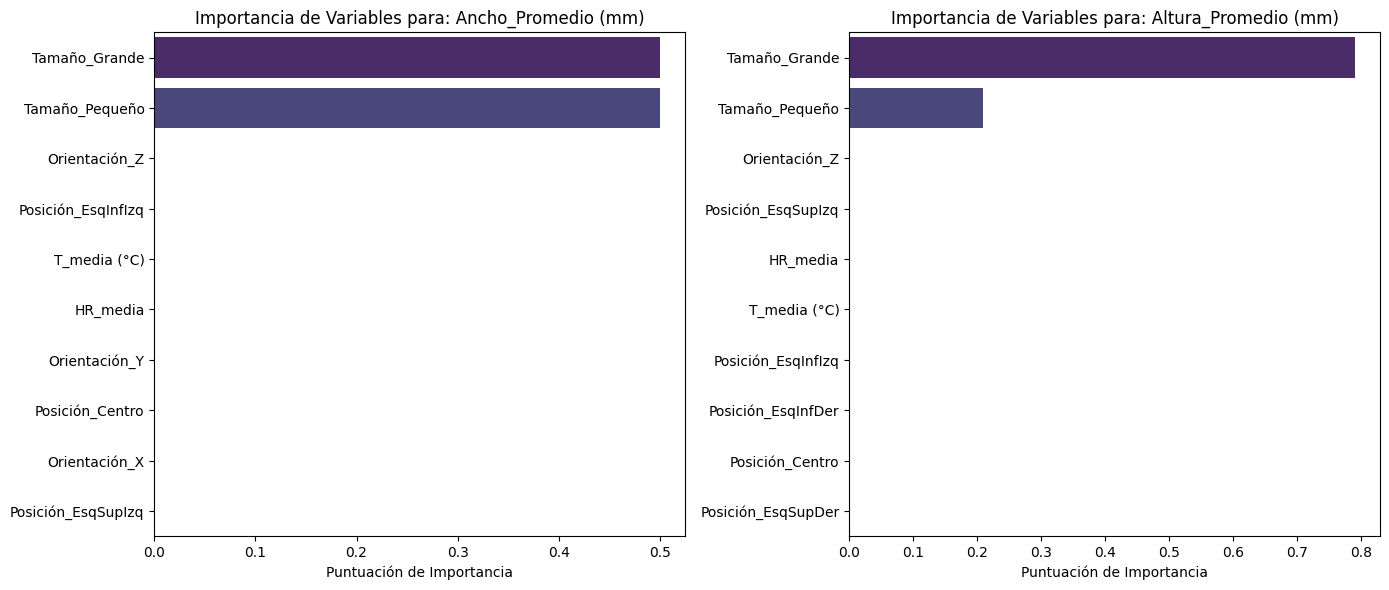

Análisis de la hoja 'Prisma Rectangular' completado con éxito.


In [4]:
run_feature_importance(file_path, sheet, features_cat, features_num, targets)

Las piezas "Grandes" y "Pequeñas" tienen dimensiones nominales muy distintas (por ejemplo, 10 mm vs 20 mm), el modelo identifica que el Tamaño explica casi toda la variabilidad.

Sin embargo, lo que realmente interesa no es predecir si una pieza mide 10 o 20, sino por qué una pieza de 20 mm termina midiendo 20.05 mm o 19.92 mm.

Para "limpiar" ese efecto del tamaño y ver qué variables causan la imprecisión se realiza un Análisis del Error Dimensional. Ahora el modelo intentará predecir el Error Absoluto.

In [5]:
def run_error_importance(file_path, sheet, features_cat, features_num, targets_error):
    try:
        # 1. Carga de datos
        df = pd.read_excel(file_path, sheet_name=sheet, skiprows=1)
        
        # 2. Definición de Valores Nominales
        # Largo: Pequeño=20, Grande=40
        # Ancho: Pequeño=10, Grande=20
        # Altura: Pequeño=5, Grande=10
        def get_nominal_values(row):
            if row['Tamaño'] == 'Grande':
                return pd.Series([40.0, 20.0, 10.0])
            else:
                return pd.Series([20.0, 10.0, 5.0])

        # 3. Cálculo del Error Dimensional (Valor Real - Valor Nominal)
        nominales = df.apply(get_nominal_values, axis=1)
        df['Error_Largo'] = df['Largo_Promedio (mm)'] - nominales[0]
        df['Error_Ancho'] = df['Ancho_Promedio (mm)'] - nominales[1]
        df['Error_Altura'] = df['Altura_Promedio (mm)'] - nominales[2]
        
        # 4. Preparación de variables
        df_clean = df[features_cat + features_num + targets_error].dropna().copy()
        
        # Uso de One-Hot Encoding para obtener importancia por categoría específica
        X = pd.get_dummies(df_clean[features_cat + features_num], columns=features_cat)
        
        # 5. Visualización de Resultados
        _, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        for i, target_col in enumerate(targets_error):
            y = df_clean[target_col]
            
            # Entrenamos el modelo sobre el ERROR
            rf = RandomForestRegressor(n_estimators=200, random_state=42)
            rf.fit(X, y)
            
            importances = rf.feature_importances_
            feature_importance_df = pd.DataFrame({
                'Variable': X.columns, 
                'Importancia': importances
            }).sort_values(by='Importancia', ascending=False)
            
            sns.barplot(ax=axes[i], x='Importancia', y='Variable', data=feature_importance_df.head(10), palette='viridis')
            axes[i].set_title(f'¿Qué causa el error en {target_col.split("_")[1]}?')
            axes[i].set_xlabel('Importancia Relativa')
            axes[i].set_ylabel('')

        plt.tight_layout()
        plt.show()
        
        print("Análisis de importancia granular basado en el ERROR completado.")
        
    except Exception as e:
        print(f"Error: {e}")

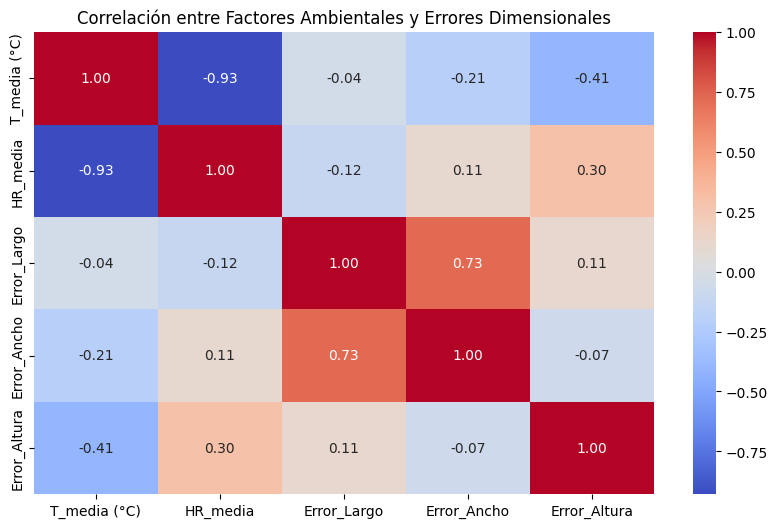

C:\Users\Erick\AppData\Local\Temp\ipykernel_41376\1447892011.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, i], x='Importancia', y='Variable', data=feature_importance_df.head(8), palette='viridis')
C:\Users\Erick\AppData\Local\Temp\ipykernel_41376\1447892011.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, i], x='Importancia', y='Variable', data=feature_importance_df.head(8), palette='viridis')
C:\Users\Erick\AppData\Local\Temp\ipykernel_41376\1447892011.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=

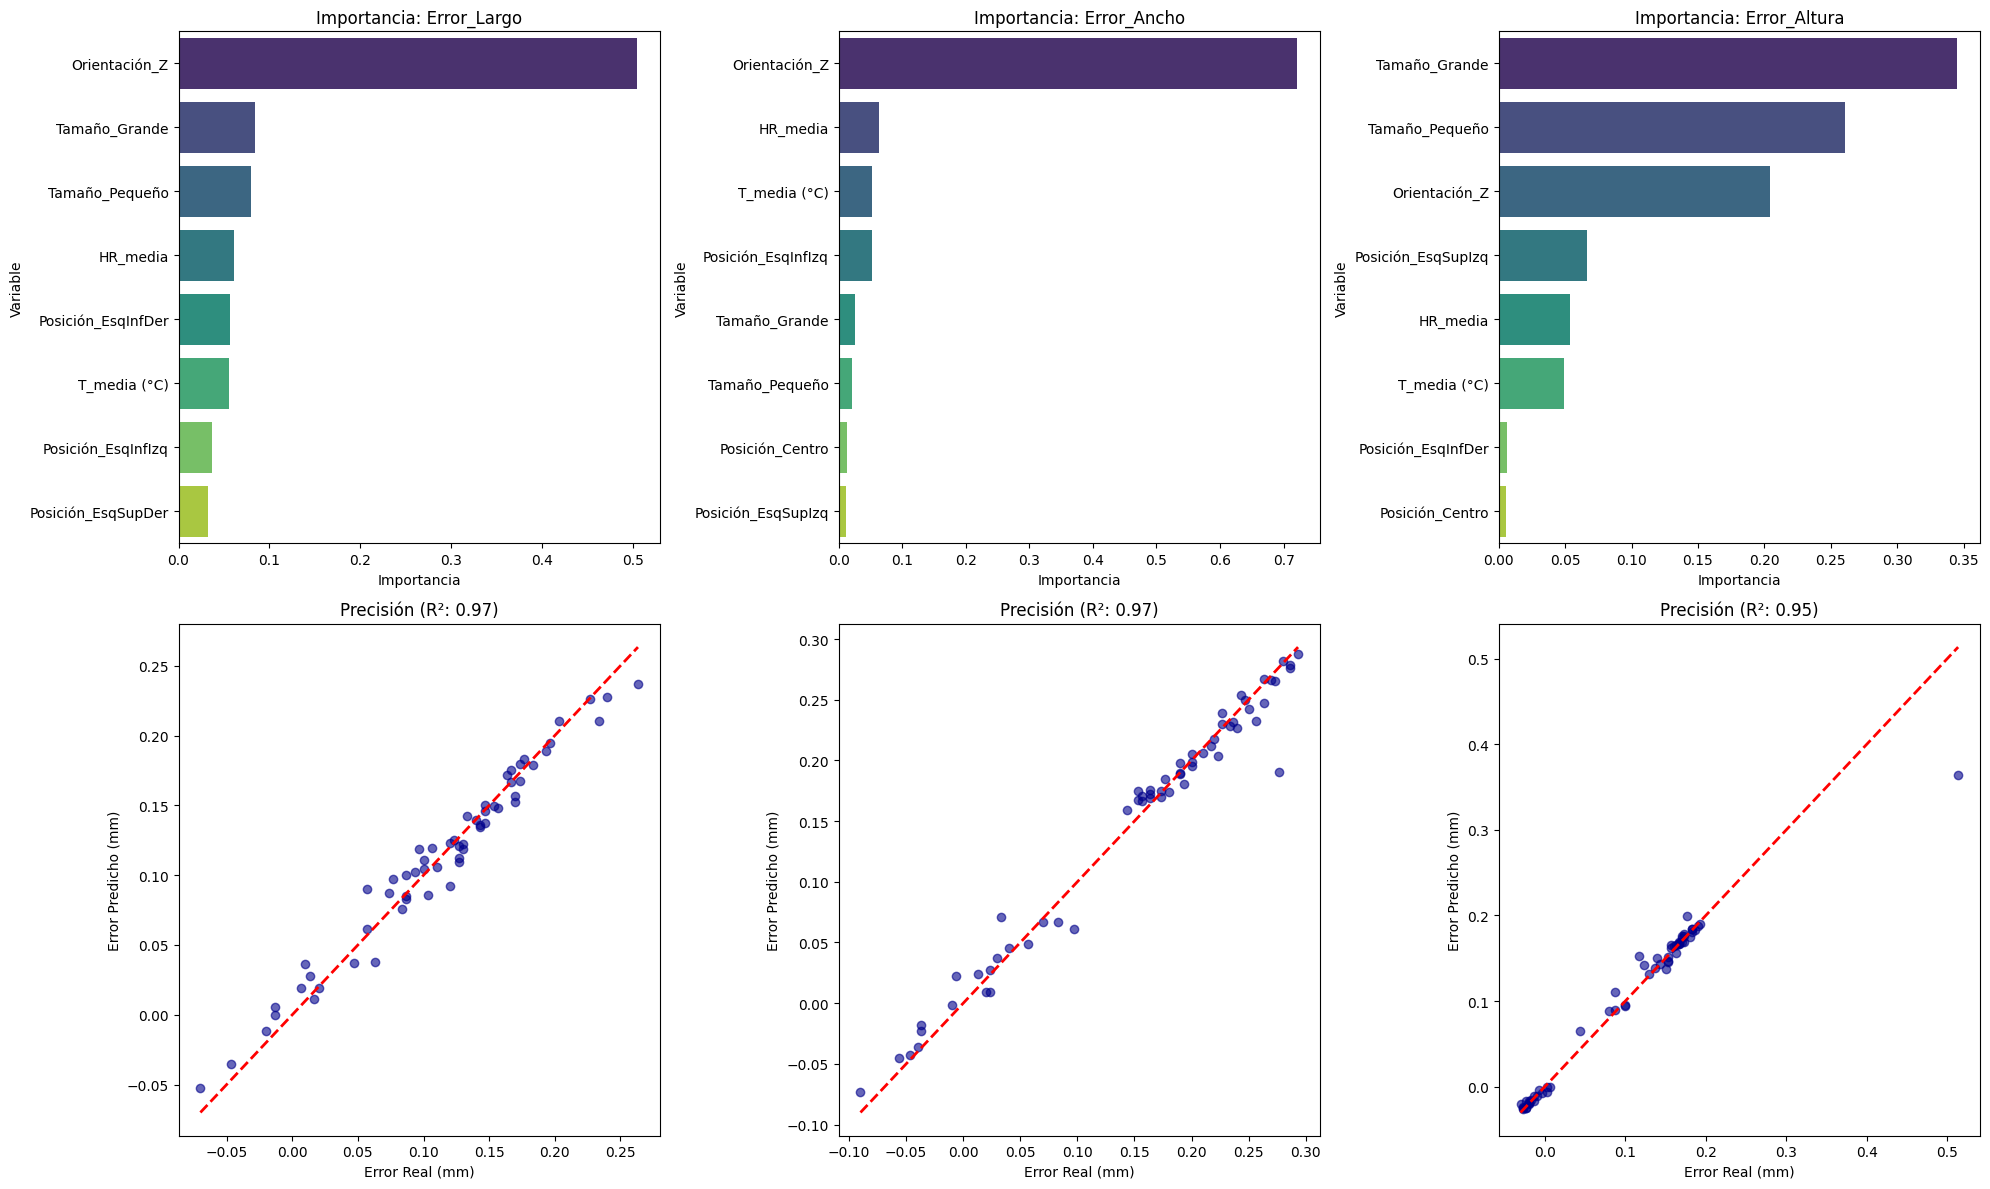


RESUMEN DE DESEMPEÑO DEL MODELO (ANÁLISIS DE ERRORES)
Dimensión  MAE (mm)  R2 Score  Error Medio (mm)
    Largo  0.010522  0.967038          0.112389
    Ancho  0.011276  0.974986          0.150167
   Altura  0.007875  0.954743          0.101222


In [9]:
run_error_importance(file_path, sheet, features_cat, features_num, ['Error_Largo', 'Error_Ancho', 'Error_Altura'])

In [7]:
def run_error_importance(file_path, sheet, features_cat, features_num, targets_error):
    try:
        # 1. Carga de datos
        df = pd.read_excel(file_path, sheet_name=sheet, skiprows=1)
        
        # 2. Definición de Valores Nominales
        def get_nominal_values(row):
            if row['Tamaño'] == 'Grande':
                return pd.Series([40.0, 20.0, 10.0])
            else:
                return pd.Series([20.0, 10.0, 5.0])

        # 3. Cálculo del Error Dimensional (Valor Real - Valor Nominal)
        nominales = df.apply(get_nominal_values, axis=1)
        df['Error_Largo'] = df['Largo_Promedio (mm)'] - nominales[0]
        df['Error_Ancho'] = df['Ancho_Promedio (mm)'] - nominales[1]
        df['Error_Altura'] = df['Altura_Promedio (mm)'] - nominales[2]
        
        # 4. Preparación de variables
        df_clean = df[features_cat + features_num + targets_error].dropna().copy()
        
        # One-Hot Encoding
        X = pd.get_dummies(df_clean[features_cat + features_num], columns=features_cat)
        
        # --- NUEVO: Análisis de Correlación Ambiental ---
        plt.figure(figsize=(10, 6))
        corr_matrix = df_clean[features_num + targets_error].corr()
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Correlación entre Factores Ambientales y Errores Dimensionales')
        plt.show()

        # 5. Modelado y Visualización de Resultados
        fig, axes = plt.subplots(2, 3, figsize=(20, 12))
        
        summary_results = []

        for i, target_col in enumerate(targets_error):
            y = df_clean[target_col]
            
            # Entrenamiento del modelo
            rf = RandomForestRegressor(n_estimators=200, random_state=42)
            rf.fit(X, y)
            y_pred = rf.predict(X)
            
            # Métricas
            mae = mean_absolute_error(y, y_pred)
            r2 = r2_score(y, y_pred)
            summary_results.append({
                'Dimensión': target_col.split('_')[1],
                'MAE (mm)': mae,
                'R2 Score': r2,
                'Error Medio (mm)': y.mean()
            })
            
            # Gráfico 1: Importancia de Variables
            importances = rf.feature_importances_
            feature_importance_df = pd.DataFrame({
                'Variable': X.columns, 
                'Importancia': importances
            }).sort_values(by='Importancia', ascending=False)
            
            sns.barplot(ax=axes[0, i], x='Importancia', y='Variable', data=feature_importance_df.head(8), palette='viridis')
            axes[0, i].set_title(f'Importancia: {target_col}')
            
            # Gráfico 2: Real vs Predicho
            axes[1, i].scatter(y, y_pred, alpha=0.6, color='darkblue')
            axes[1, i].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
            axes[1, i].set_xlabel('Error Real (mm)')
            axes[1, i].set_ylabel('Error Predicho (mm)')
            axes[1, i].set_title(f'Precisión (R²: {r2:.2f})')

        plt.tight_layout()
        plt.show()
        
        # 6. Reporte Estadístico Final
        print("\n" + "="*50)
        print("RESUMEN DE DESEMPEÑO DEL MODELO (ANÁLISIS DE ERRORES)")
        print("="*50)
        report_df = pd.DataFrame(summary_results)
        print(report_df.to_string(index=False))
        print("="*50)
        
    except Exception as e:
        print(f"Error: {e}")

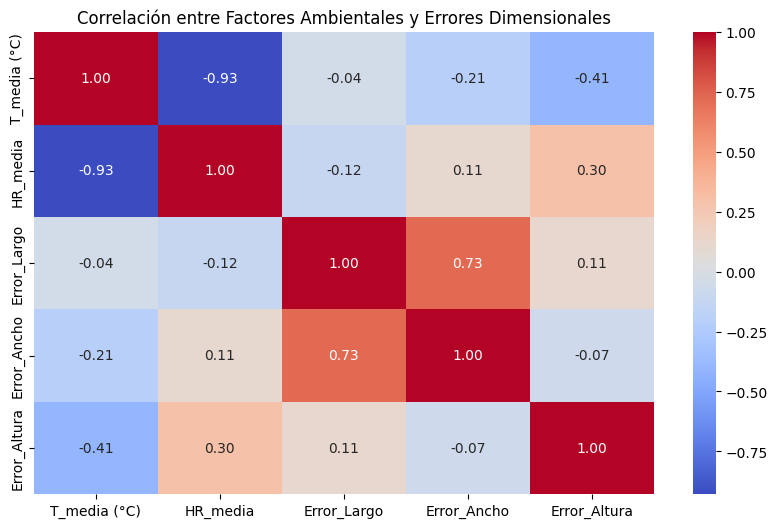

C:\Users\Erick\AppData\Local\Temp\ipykernel_41376\1447892011.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, i], x='Importancia', y='Variable', data=feature_importance_df.head(8), palette='viridis')
C:\Users\Erick\AppData\Local\Temp\ipykernel_41376\1447892011.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0, i], x='Importancia', y='Variable', data=feature_importance_df.head(8), palette='viridis')
C:\Users\Erick\AppData\Local\Temp\ipykernel_41376\1447892011.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=

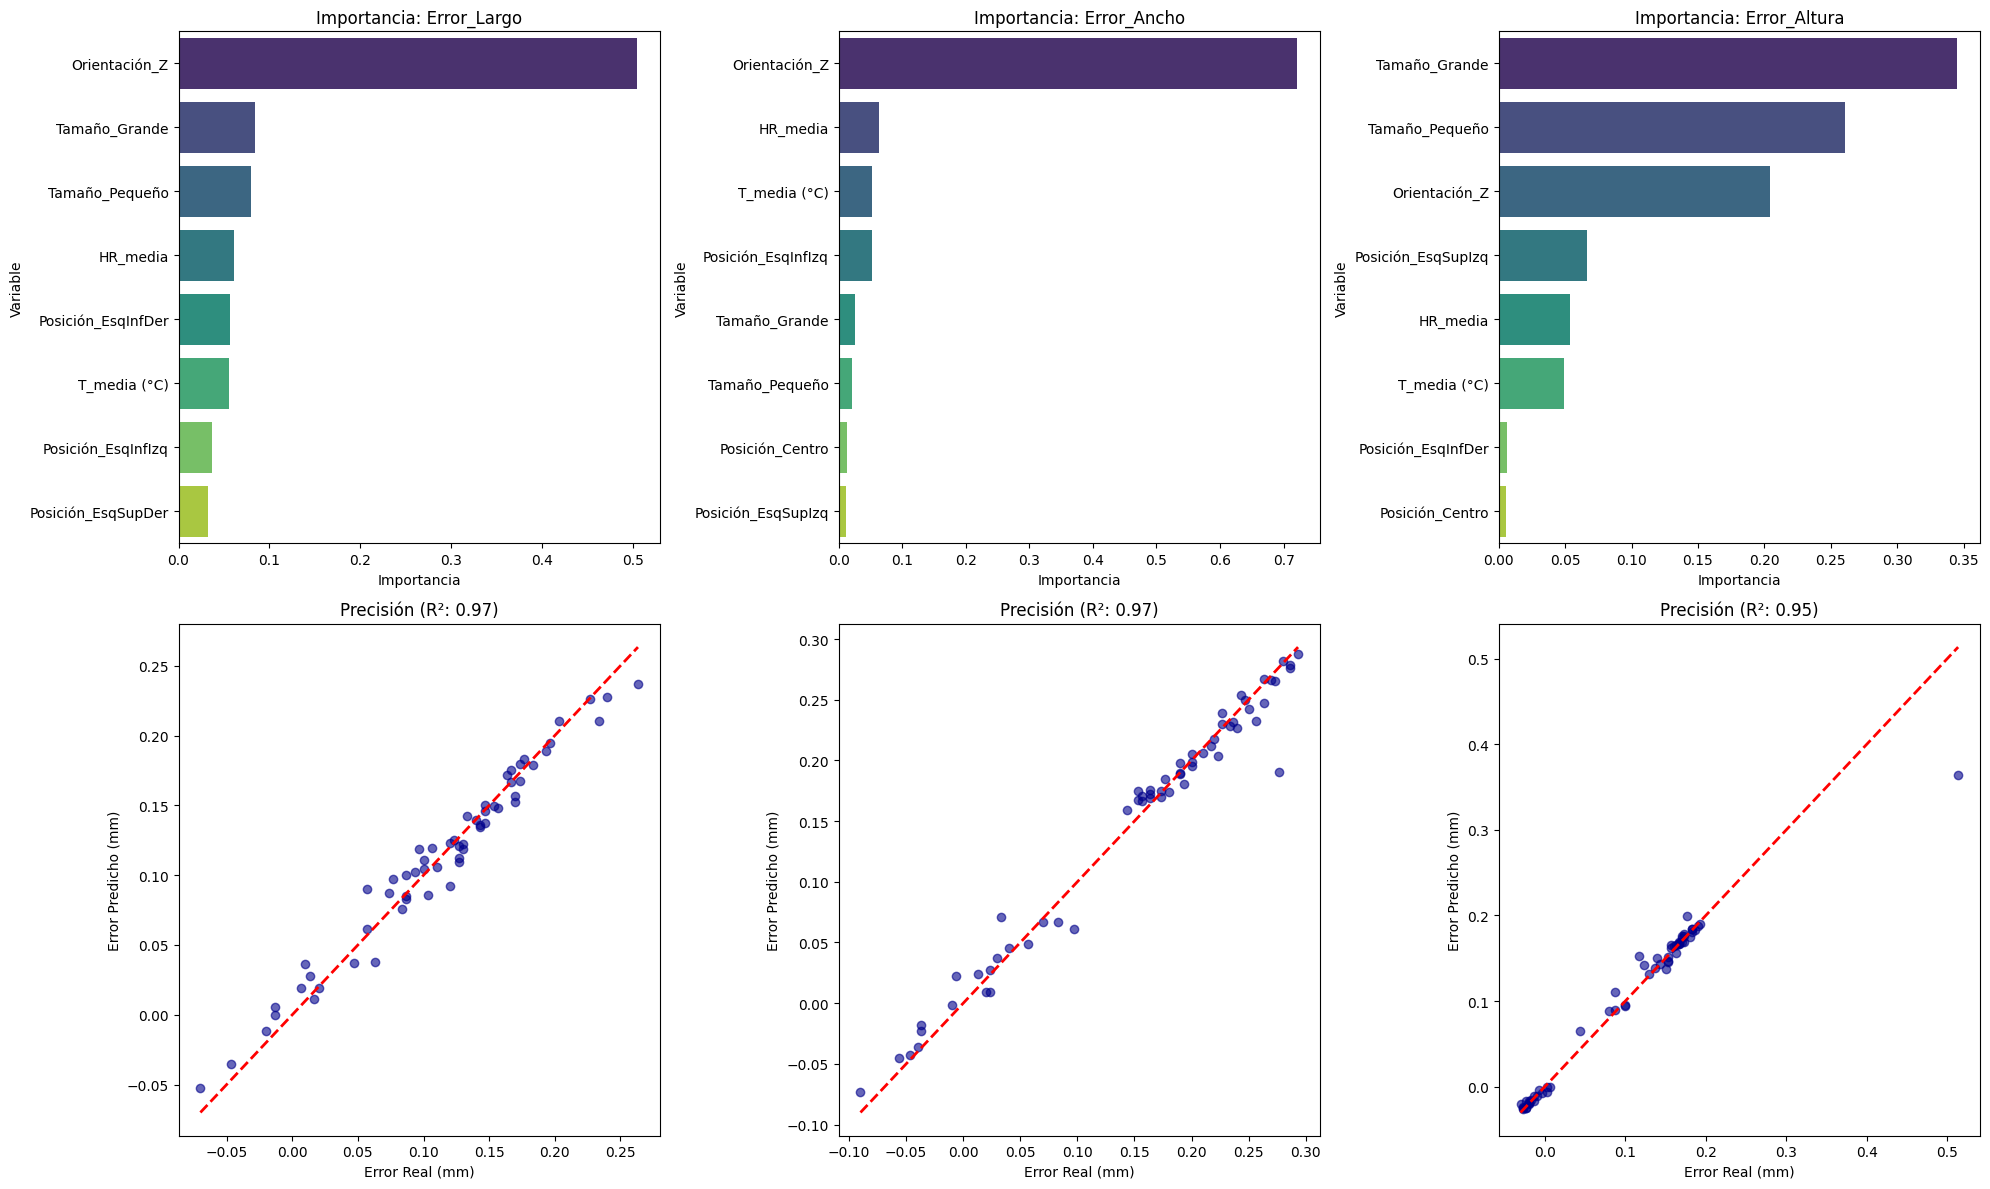


RESUMEN DE DESEMPEÑO DEL MODELO (ANÁLISIS DE ERRORES)
Dimensión  MAE (mm)  R2 Score  Error Medio (mm)
    Largo  0.010522  0.967038          0.112389
    Ancho  0.011276  0.974986          0.150167
   Altura  0.007875  0.954743          0.101222


In [8]:
run_error_importance(file_path, sheet, features_cat, features_num, ['Error_Largo', 'Error_Ancho', 'Error_Altura'])